# Hierarchical Clustering : Practice & Experiments

**Authored by Alexandre Mathias DONNAT, Sr**

Here we will see how to use hierarchical clustering.

## Imports

In [3]:
from IPython.display import SVG

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, cut_tree
import seaborn as sns

In [5]:
from sklearn import datasets
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score
from sklearn.metrics.cluster import contingency_matrix

In [6]:
from sknetwork.data import karate_club, load_netset
from sknetwork.embedding import Spectral
from sknetwork.utils import get_degrees
from sknetwork.visualization import svg_graph, svg_dendrogram

In [7]:
def show_data(X, y, features=[0, 1], feature_names=['x','y']):
    '''Display the samples in 2D'''
    plt.figure(figsize=(5,5))
    for label in set(y):
        plt.scatter(X[y == label, features[0]], X[y == label, features[1]])
    plt.xlabel(feature_names[features[0]])
    plt.ylabel(feature_names[features[1]])
    plt.show()

## Iris dataset

We start with the Iris dataset.

In [8]:
iris = datasets.load_iris()
X = iris.data  
y = iris.target
feature_names = iris.feature_names
label_names = list(iris.target_names)

In [9]:
# hierarchical clustering
Z = linkage(X, method='ward')

In [10]:
X.shape

(150, 4)

In [11]:
Z

array([[1.01000000e+02, 1.42000000e+02, 0.00000000e+00, 2.00000000e+00],
       [7.00000000e+00, 3.90000000e+01, 1.00000000e-01, 2.00000000e+00],
       [0.00000000e+00, 1.70000000e+01, 1.00000000e-01, 2.00000000e+00],
       [9.00000000e+00, 3.40000000e+01, 1.00000000e-01, 2.00000000e+00],
       [1.28000000e+02, 1.32000000e+02, 1.00000000e-01, 2.00000000e+00],
       [1.00000000e+01, 4.80000000e+01, 1.00000000e-01, 2.00000000e+00],
       [4.00000000e+00, 3.70000000e+01, 1.41421356e-01, 2.00000000e+00],
       [1.90000000e+01, 2.10000000e+01, 1.41421356e-01, 2.00000000e+00],
       [2.90000000e+01, 3.00000000e+01, 1.41421356e-01, 2.00000000e+00],
       [5.70000000e+01, 9.30000000e+01, 1.41421356e-01, 2.00000000e+00],
       [8.00000000e+01, 8.10000000e+01, 1.41421356e-01, 2.00000000e+00],
       [1.16000000e+02, 1.37000000e+02, 1.41421356e-01, 2.00000000e+00],
       [8.00000000e+00, 3.80000000e+01, 1.41421356e-01, 2.00000000e+00],
       [3.00000000e+00, 4.70000000e+01, 1.41421356e

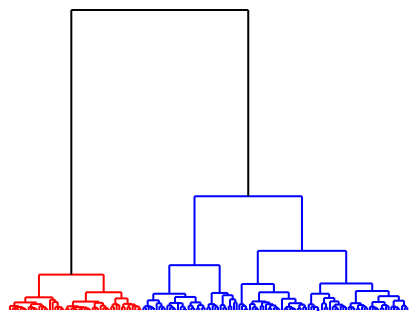

In [12]:
SVG(svg_dendrogram(Z))

## To do

* What are the two first flowers merged? Compare their features.
* Give the first 2 clusters. Show the contingency matrix and give the ARI / AMI scores.
* Give the first 3 clusters. Show the contingency matrix, give the ARI / AMI scores and compare with K-Means.
* Test other linkages.

In [13]:
print(Z[:2].astype(int))
# Given this and the documentation, point 101 and 142, then 7 and 39 are the first to be merged
print(X[101], X[142], X[7], X[39])
print(np.linalg.norm(X[101]-X[142]),np.linalg.norm(X[7]-X[39]))
# First two are the same, second pair is very close

[[101 142   0   2]
 [  7  39   0   2]]
[5.8 2.7 5.1 1.9] [5.8 2.7 5.1 1.9] [5.  3.4 1.5 0.2] [5.1 3.4 1.5 0.2]
0.0 0.09999999999999964


In [14]:
from scipy.cluster.hierarchy import fcluster

[[282 290   3  50]
 [287 288   4  36]
 [292 293   6  64]
 [295 296  12 100]
 [294 297  32 150]]


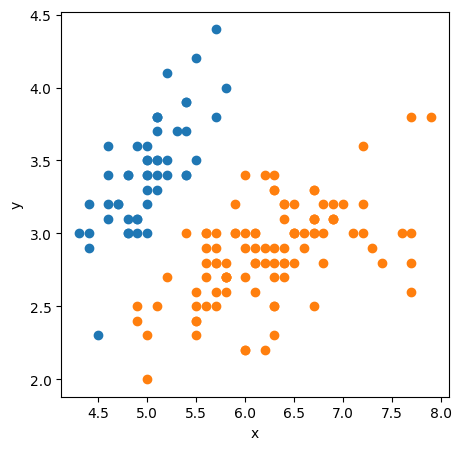

ARI: 0.5681159420289855
AMI: 0.7315847607219571


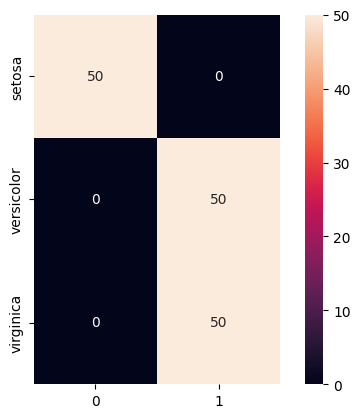

In [15]:
print(Z[-5:].astype(int))
labels = fcluster(Z, 2, criterion='maxclust')
show_data(X, labels, [0, 1])
contingency = contingency_matrix(y, labels)
sns.heatmap(contingency, annot=True, square=True, xticklabels=np.arange(2), yticklabels=label_names)
print("ARI:", adjusted_rand_score(y, labels))
print("AMI:", adjusted_mutual_info_score(y, labels))

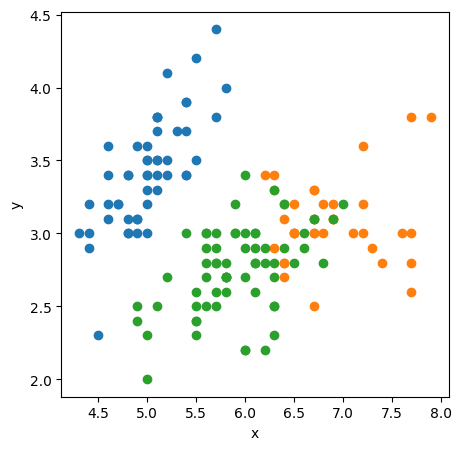

ARI: 0.7311985567707746
AMI: 0.767166961571311
K-means ARI: 0.7302382722834697
K-means AMI: 0.7551191675800484


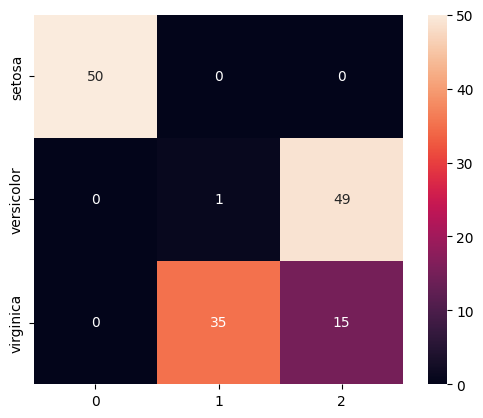

In [16]:
labels = fcluster(Z, 3, criterion='maxclust')
show_data(X, labels, [0, 1])
contingency = contingency_matrix(y, labels)
sns.heatmap(contingency, annot=True, square=True, xticklabels=np.arange(3), yticklabels=label_names)
print("ARI:", adjusted_rand_score(y, labels))
print("AMI:", adjusted_mutual_info_score(y, labels))
# For K-means
kmeans = KMeans(n_clusters=3, n_init=10)
labels = kmeans.fit_predict(X)
print("K-means ARI:", adjusted_rand_score(y, labels))
print("K-means AMI:", adjusted_mutual_info_score(y, labels))

## To do

* Complete the function ``get_n_clusters`` below, that returns relevant cuts of the dendrogram.
* Select the 2 best clusterings of the Iris dataset.
* Compare with $k$-means.

In [17]:
def plot_cumulative_height(Z):
    '''Plot the cumulative height of clusters as a function of the number of clusters.
    
    Parameters
    ----------
    Z : np.ndarray
        Linkage matrix
    '''
    heights = Z[:, 2]# Get the linkage heights in descending order
    num_clusters = np.arange(1, len(heights)+2)  # Number of clusters
    cumulative_heights = [0.] + list(np.cumsum(np.flip(heights)))  # Cumulative sum of heights
    plt.figure(figsize=(8, 5))
    plt.plot(num_clusters, cumulative_heights, marker='o', linestyle='-')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Cumulative Height')
    plt.title('Cumulative Height of Clusters')
    plt.grid()
    plt.show()

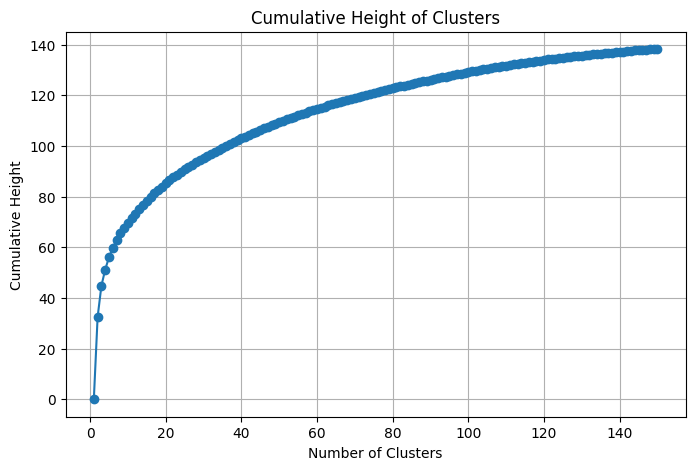

In [18]:
plot_cumulative_height(Z)

In [19]:
def get_n_clusters(Z):
    '''Return the list of numbers of clusters in decreasing order of height gaps. 
    
    Parameters
    ----------
    Z : np.ndarray
        Dendrogram
    Returns
    -------
    n_clusters : np.ndarray
        Numbers of clusters.
    '''
    gaps = np.diff(Z[:, 2])  # Compute height differences
    n = Z.shape[0] + 1  # Number of initial points
    labels = np.arange(n)  # Start with each point as its own cluster
    clusters_at_heights = [(n, labels.copy())]

    for i, ((c1, c2, height, _), g) in enumerate(zip(Z, gaps)):
        labels[labels == c1] = n + i
        labels[labels == c2] = n + i
        unique_labels, new_labels = np.unique(labels, return_inverse=True)
        if g > 0.0000001:
            clusters_at_heights.append((len(unique_labels), new_labels))
    
    clusters_at_heights.reverse()
    return clusters_at_heights

In [20]:
descending_clusters = get_n_clusters(Z)

In [21]:
descending_clusters

[(2,
  array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])),
 (3,
  array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
         2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
         2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1,
         1, 1, 1, 2, 2, 1, 1, 1, 1, 2, 1, 2, 1, 2, 1, 1, 2, 2, 1, 1, 1, 1,
         1, 2, 2, 1, 1, 

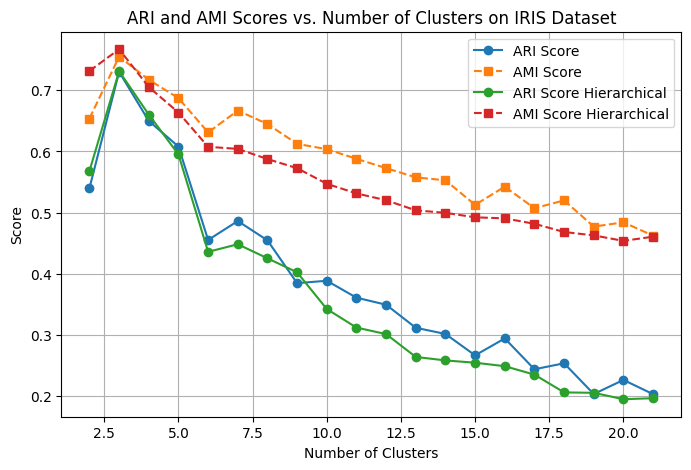

In [22]:
ari_scores_h = []
ami_scores_h = []
ari_scores = []
ami_scores = []
n_clusters_l = []

# Perform clustering and compute ARI & AMI scores
for n_clusters, labels_h in descending_clusters:
    kmeans = KMeans(n_clusters=n_clusters, n_init=10)
    labels = kmeans.fit_predict(X)
    
    ari = adjusted_rand_score(y, labels)
    ami = adjusted_mutual_info_score(y, labels)
    ari_scores.append(ari)
    ami_scores.append(ami)
    
    ari = adjusted_rand_score(y, labels_h)
    ami = adjusted_mutual_info_score(y, labels_h)
    ari_scores_h.append(ari)
    ami_scores_h.append(ami)
    
    n_clusters_l.append(n_clusters)
    if n_clusters > 20:
        break

# Plot ARI and AMI scores
plt.figure(figsize=(8, 5))
plt.plot(n_clusters_l, ari_scores, marker='o', label='ARI Score', linestyle='-')
plt.plot(n_clusters_l, ami_scores, marker='s', label='AMI Score', linestyle='--')
plt.plot(n_clusters_l, ari_scores_h, marker='o', label='ARI Score Hierarchical', linestyle='-')
plt.plot(n_clusters_l, ami_scores_h, marker='s', label='AMI Score Hierarchical', linestyle='--')
plt.xlabel("Number of Clusters")
plt.ylabel("Score")
plt.title("ARI and AMI Scores vs. Number of Clusters on IRIS Dataset")
plt.legend()
plt.grid(True)
plt.show()

## Karate Club

We now consider the [Karate Club](https://en.wikipedia.org/wiki/Zachary%27s_karate_club) graph. The Ward method is applied to the spectral embedding of the graph.

In [23]:
graph = karate_club(metadata=True)

In [24]:
adjacency = graph.adjacency
y = graph.labels
position = graph.position

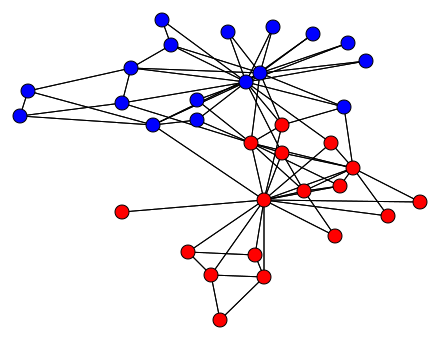

In [25]:
SVG(svg_graph(adjacency, position, labels=y))

## To do

* Apply hierarchical clustering to the spectral embedding in dimension 3.
* Display the dendrogram.
* Display the best clustering.
* Compute the ARI / AMI scores.
* Compare with k-means (with the same number of clusters).

In [26]:
spectral = Spectral(n_components=3)
X = spectral.fit_transform(adjacency)

In [27]:
Z = linkage(X, method='ward')

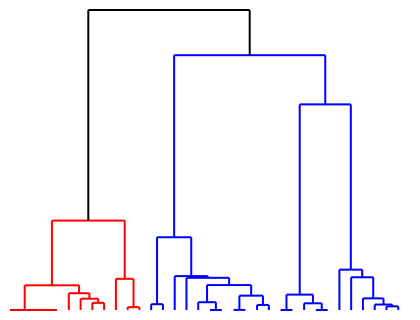

In [28]:
SVG(svg_dendrogram(Z))

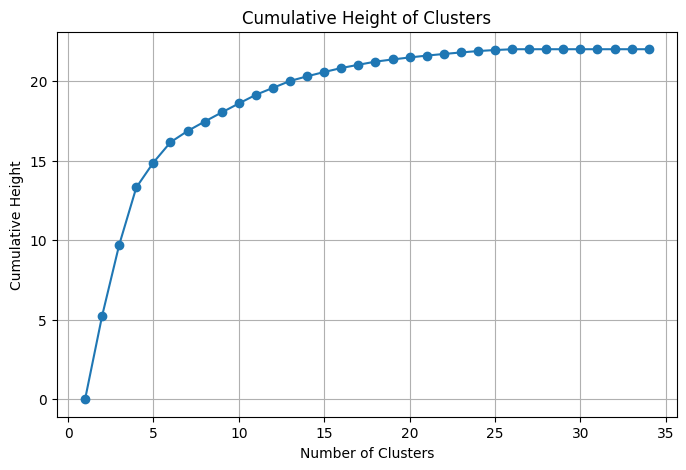

In [29]:
plot_cumulative_height(Z)

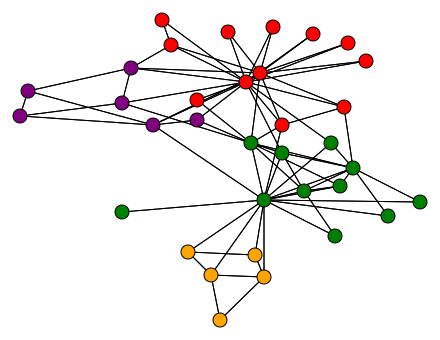

In [30]:
labels = fcluster(Z, 4, criterion='maxclust')
SVG(svg_graph(adjacency, position, labels=labels))

In [31]:
descending_clusters = get_n_clusters(Z)

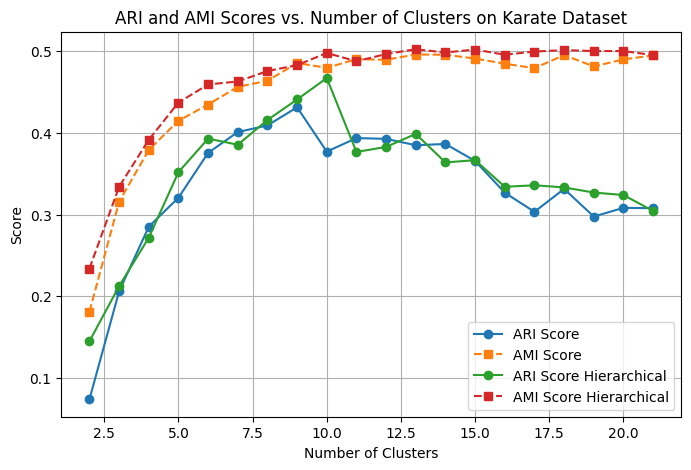

In [47]:
import warnings
warnings.filterwarnings("ignore")

ari_scores_h = []
ami_scores_h = []
ari_scores = []
ami_scores = []
n_clusters_l = []

# Perform clustering and compute ARI & AMI scores
for n_clusters, labels_h in descending_clusters:
    kmeans = KMeans(n_clusters=n_clusters, n_init=10)
    labels = kmeans.fit_predict(X)
    
    ari = adjusted_rand_score(y, labels)
    ami = adjusted_mutual_info_score(y, labels)
    ari_scores.append(ari)
    ami_scores.append(ami)
    
    ari = adjusted_rand_score(y, labels_h)
    ami = adjusted_mutual_info_score(y, labels_h)
    ari_scores_h.append(ari)
    ami_scores_h.append(ami)
    
    n_clusters_l.append(n_clusters)
    if n_clusters > 20:
        break

# Plot ARI and AMI scores
plt.figure(figsize=(8, 5))
plt.plot(n_clusters_l, ari_scores, marker='o', label='ARI Score', linestyle='-')
plt.plot(n_clusters_l, ami_scores, marker='s', label='AMI Score', linestyle='--')
plt.plot(n_clusters_l, ari_scores_h, marker='o', label='ARI Score Hierarchical', linestyle='-')
plt.plot(n_clusters_l, ami_scores_h, marker='s', label='AMI Score Hierarchical', linestyle='--')
plt.xlabel("Number of Clusters")
plt.ylabel("Score")
plt.title("ARI and AMI Scores vs. Number of Clusters on Karate Dataset")
plt.legend()
plt.grid(True)
plt.show()

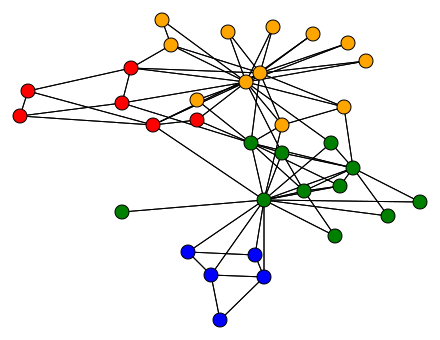

In [33]:
SVG(svg_graph(adjacency, position, labels=descending_clusters[2][1]))

## Wikipedia

Finally, we consider a small subset of Wikipedia called [Wikipedia for Schools](https://en.wikipedia.org/wiki/Wikipedia:Wikipedia_for_Schools). Each article is encoded by the words used in the summary of this article.

In [34]:
dataset = load_netset('wikischools')

Unpacking archive...
Parsing files...
Done.


In [35]:
adjacency = dataset.adjacency
features = dataset.biadjacency
names = dataset.names
words = dataset.names_col
y = dataset.labels
names_labels = dataset.names_labels

In [36]:
i = 100
names[i]

np.str_('United Nations')

In [37]:
# label
names_labels[y[i]]

np.str_('Politics')

In [38]:
# words
words[features[i].indices]

array(['memori', 'trust', 'held', 'sinc', 'wide', 'statu', 'politician',
       'met', 'hagu', 'princip', 'prize', 'new', 'assembl', 'aim',
       'draft', 'member', 'effect', 'main', 'april', 'financ',
       'peacekeep', 'import', 'voluntari', 'gain', 'council', 'social',
       'court', 'antónio', 'nairobi', 'coloni', 'maintain', 'deliv',
       'achiev', 'complex', 'relat', 'world', 'contribut', 'union',
       'octob', 'monitor', 'justic', 'centr', 'far', 'decolon', 'earli',
       'confer', 'former', 'aid', 'peac', 'spend', 'sustain', 'power',
       'leagu', 'primarili', 'geneva', 'opera', 'significantli', 'econom',
       'comment', 'diplomat', 'role', 'alli', 'lightli', 'san', 'budget',
       'forc', 'francisco', 'agenc', 'undertak', 'membership',
       'headquart', 'particip', 'militari', 'decad', 'prevent', 'task',
       'complic', 'januari', 'arm', 'six', 'charter', 'troop', 'ii',
       'adopt', 'among', 'intern', 'observ', 'oper', 'bias', 'develop',
       'respect', '

In [39]:
# number of incoming links
in_degrees = get_degrees(adjacency, transpose=True)
in_degrees[i]

np.int32(318)

In [40]:
spectral = Spectral(n_components=20)
X = spectral.fit_transform(features)

## To do

* Apply hierarchical clustering to the spectral embedding in dimension 20.
* Select the best clustering and compare with the ground-truth in terms of ARI / AMI.
* Select the clustering with 20 clusters and list the top 5 articles of each cluster (in terms of number of incoming links).

In [41]:
Z = linkage(X, method='ward')

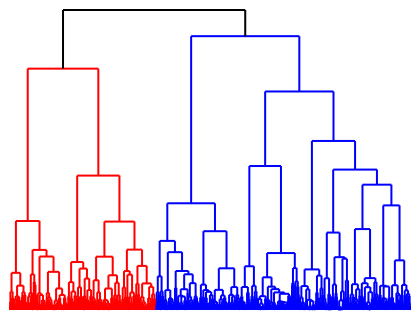

In [42]:
SVG(svg_dendrogram(Z))

In [43]:
descending_clusters = get_n_clusters(Z)

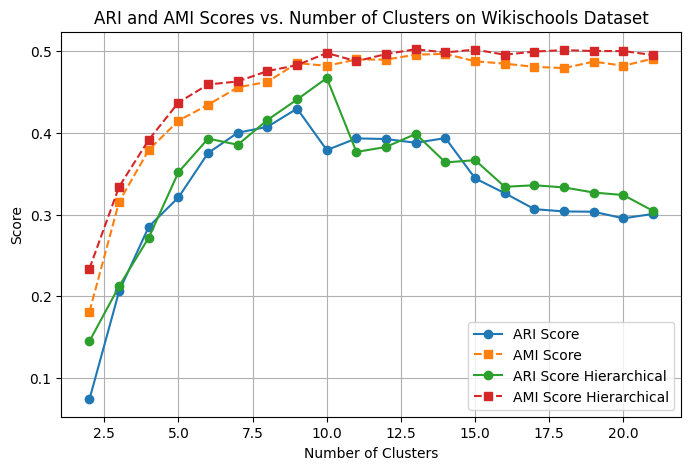

In [44]:
ari_scores_h = []
ami_scores_h = []
ari_scores = []
ami_scores = []
n_clusters_l = []

# Perform clustering and compute ARI & AMI scores
for n_clusters, labels_h in descending_clusters:
    kmeans = KMeans(n_clusters=n_clusters, n_init=10)
    labels = kmeans.fit_predict(X)
    
    ari = adjusted_rand_score(y, labels)
    ami = adjusted_mutual_info_score(y, labels)
    ari_scores.append(ari)
    ami_scores.append(ami)
    
    ari = adjusted_rand_score(y, labels_h)
    ami = adjusted_mutual_info_score(y, labels_h)
    ari_scores_h.append(ari)
    ami_scores_h.append(ami)
    
    n_clusters_l.append(n_clusters)
    if n_clusters > 20:
        break

# Plot ARI and AMI scores
plt.figure(figsize=(8, 5))
plt.plot(n_clusters_l, ari_scores, marker='o', label='ARI Score', linestyle='-')
plt.plot(n_clusters_l, ami_scores, marker='s', label='AMI Score', linestyle='--')
plt.plot(n_clusters_l, ari_scores_h, marker='o', label='ARI Score Hierarchical', linestyle='-')
plt.plot(n_clusters_l, ami_scores_h, marker='s', label='AMI Score Hierarchical', linestyle='--')
plt.xlabel("Number of Clusters")
plt.ylabel("Score")
plt.title("ARI and AMI Scores vs. Number of Clusters on Wikischools Dataset")
plt.legend()
plt.grid(True)
plt.show()

In [45]:
clustering = descending_clusters[18][1]
print(clustering.shape)

(4403,)


In [46]:
for i in range(20):
    indices = np.where(clustering == i)
    print("Cluster size:", len(indices[0]))
    print("Articles:", names[indices[0][np.flip(np.argsort(in_degrees[indices[0]]))]][:5])
    print("Liens:", in_degrees[indices[0][np.flip(np.argsort(in_degrees[indices[0]]))][:5]])

Cluster size: 124
Articles: ['Bacteria' 'Protein' 'DNA' 'Medicine' 'Cancer']
Liens: [102 100  97  96  92]
Cluster size: 159
Articles: ['Atlantic Ocean' 'Pacific Ocean' 'Florida' 'Indian Ocean' 'Antarctica']
Liens: [244 181 154 118  96]
Cluster size: 115
Articles: ['Tourism' 'Industry' 'Industrial Revolution' 'Automobile' 'Transport']
Liens: [145  95  86  85  60]
Cluster size: 92
Articles: ['Sun' 'Moon' 'Solar System' 'Star' 'Planet']
Liens: [173 124  97  94  75]
Cluster size: 201
Articles: ['Currency' 'Television' 'Internet' 'Economics' 'Radio']
Liens: [284 152 117 101  99]
Cluster size: 89
Articles: ['India' 'English language' 'German language' 'Rome' 'Spanish language']
Liens: [589 569 215 196 194]
Cluster size: 106
Articles: ['BBC' 'Film' 'University of Cambridge' 'Chess' 'University of Chicago']
Liens: [169 136  77  37  30]
Cluster size: 187
Articles: ['William Shakespeare' 'Art' 'Opera' 'Literature' 'Novel']
Liens: [133 103  79  75  74]
Cluster size: 149
Articles: ['United Nations